# ✈️ British Airways — Predictive Customer Booking Model
## Getting Started Notebook

> **Objective:** Use historical booking data to predict whether a customer will complete a booking.
> This notebook walks through **data exploration → preparation → feature engineering → model training → evaluation → interpretation**.

---

## 0. Install & Import Libraries

In [112]:
# !pip install pandas numpy scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Plot style
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully')

Libraries imported successfully


---
## 1. Load & Inspect the Dataset

We start by loading the CSV and getting a first look at shape, types, and statistics.

In [89]:
df = pd.read_csv("../data/raw/customer_booking.csv", encoding="ISO-8859-1")

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 50,000 rows × 14 columns


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [91]:
# Check for missing values
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found')

No missing values found


In [92]:
df.describe().round()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
mean,2.0,85.0,23.0,9.0,1.0,0.0,0.0,7.0,0.0
std,1.0,90.0,34.0,5.0,0.0,0.0,0.0,1.0,0.0
min,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
25%,1.0,21.0,5.0,5.0,0.0,0.0,0.0,6.0,0.0
50%,1.0,51.0,17.0,9.0,1.0,0.0,0.0,8.0,0.0
75%,2.0,115.0,28.0,13.0,1.0,1.0,1.0,9.0,0.0
max,9.0,867.0,778.0,23.0,1.0,1.0,1.0,10.0,1.0


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [93]:
vc = df['booking_complete'].value_counts()
pct = df['booking_complete'].value_counts(normalize=True) * 100
print('booking_complete   Count    %')
print('-----------------------------------')
for k in vc.index:
    label = 'Completed' if k == 1 else 'Not completed'
    print(f'  {k} ({label:<15}) {vc[k]:>7,}   {pct[k]:>5.1f}%')

booking_complete   Count    %
-----------------------------------
  0 (Not completed  )  42,522    85.0%
  1 (Completed      )   7,478    15.0%


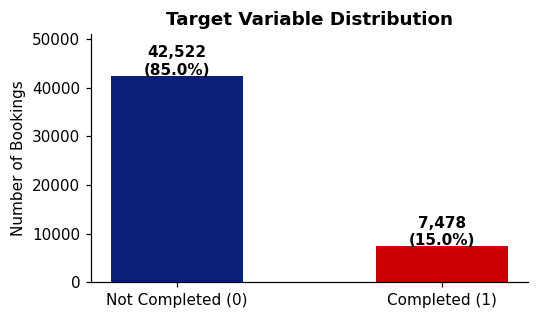

In [94]:
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(['Not Completed (0)', 'Completed (1)'], vc.values,
              color=['#0B1F78', '#CC0000'], edgecolor='none', width=0.5)
for bar, count, p in zip(bars, vc.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({p:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Bookings')
ax.set_title('Target Variable Distribution', fontweight='bold')
ax.set_ylim(0, max(vc.values) * 1.2)
plt.tight_layout()
plt.show()

---
## 2. Exploratory Data Analysis (EDA)

Examine how key features relate to the target.

In [95]:
categorical_columns = df.select_dtypes(include='object').columns.to_list()

print('Categorical columns and unique value counts:')
for c in categorical_columns:
    print(f'  {c:<25} {df[c].nunique()} unique values')

Categorical columns and unique value counts:
  sales_channel             2 unique values
  trip_type                 3 unique values
  flight_day                7 unique values
  route                     799 unique values
  booking_origin            104 unique values


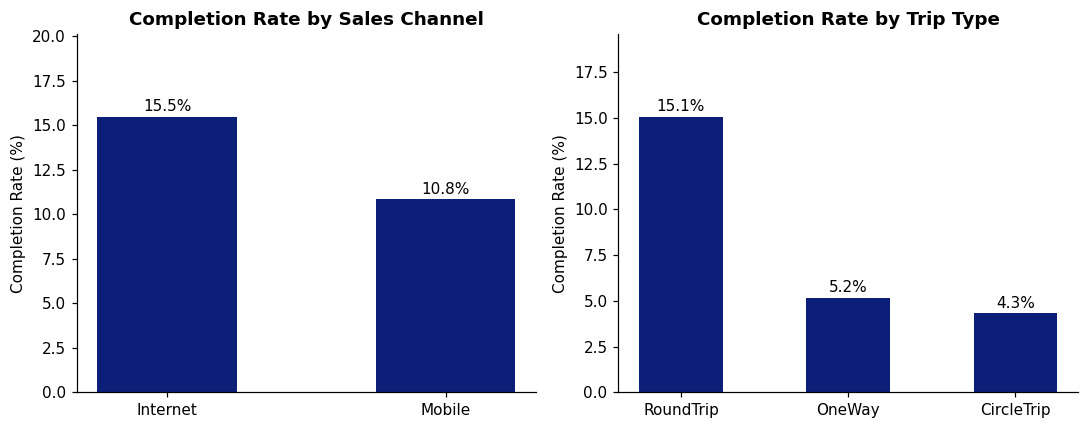

In [96]:
# Booking completion rate by sales channel and trip type
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(axes,
    ['sales_channel', 'trip_type'],
    ['Completion Rate by Sales Channel', 'Completion Rate by Trip Type']):
    rates = df.groupby(col)['booking_complete'].mean().sort_values(ascending=False)
    bars = ax.bar(rates.index, rates.values * 100, color='#0B1F78', edgecolor='none', width=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=10)
    ax.set_ylabel('Completion Rate (%)')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(rates.values)*130)

plt.tight_layout()
plt.show()

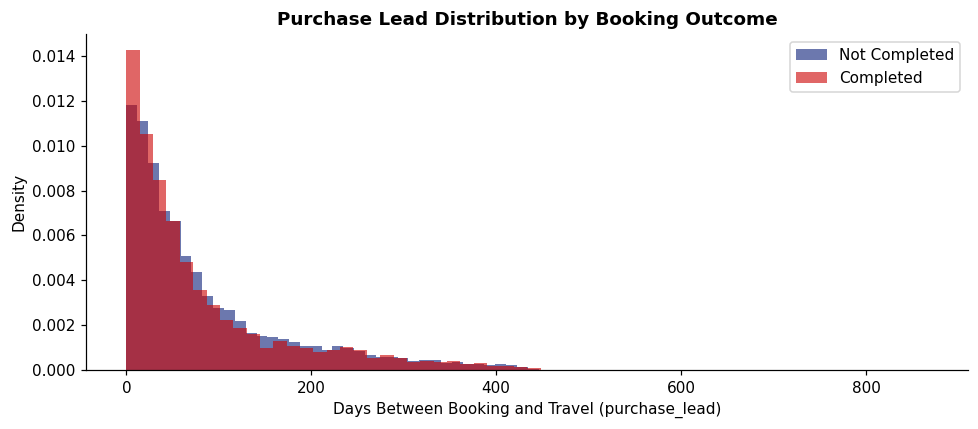


Mean purchase_lead by outcome:
booking_complete
Not Completed    85.779926
Completed        80.167157


In [97]:
# Distribution of purchase_lead by booking outcome
fig, ax = plt.subplots(figsize=(9, 4))
for val, label, color in [(0, 'Not Completed', '#0B1F78'), (1, 'Completed', '#CC0000')]:
    ax.hist(df[df['booking_complete']==val]['purchase_lead'],
            bins=60, alpha=0.6, label=label, color=color, density=True)
ax.set_xlabel('Days Between Booking and Travel (purchase_lead)')
ax.set_ylabel('Density')
ax.set_title('Purchase Lead Distribution by Booking Outcome', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print('\nMean purchase_lead by outcome:')
print(df.groupby('booking_complete')['purchase_lead'].mean().rename({0:'Not Completed', 1:'Completed'}).to_string())

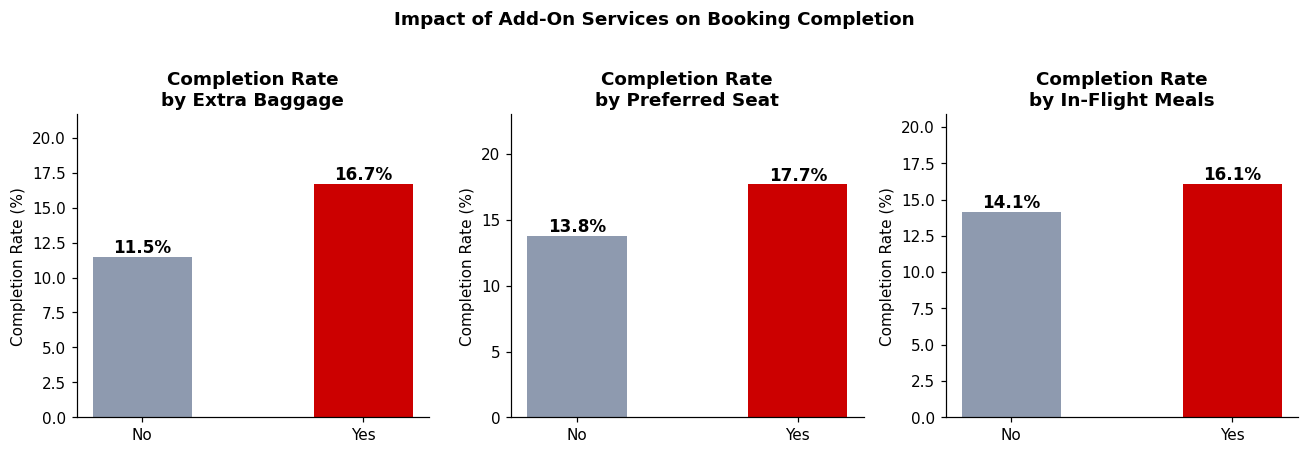

In [98]:
# Add-on services vs booking completion
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
add_ons = ['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']
titles = ['Extra Baggage', 'Preferred Seat', 'In-Flight Meals']

for ax, col, title in zip(axes, add_ons, titles):
    rates = df.groupby(col)['booking_complete'].mean() * 100
    bars = ax.bar(['No', 'Yes'], rates.values, color=['#8E9AAF', '#CC0000'], edgecolor='none', width=0.45)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Completion Rate\nby {title}', fontweight='bold')
    ax.set_ylabel('Completion Rate (%)')
    ax.set_ylim(0, max(rates.values) * 1.3)

plt.suptitle('Impact of Add-On Services on Booking Completion', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

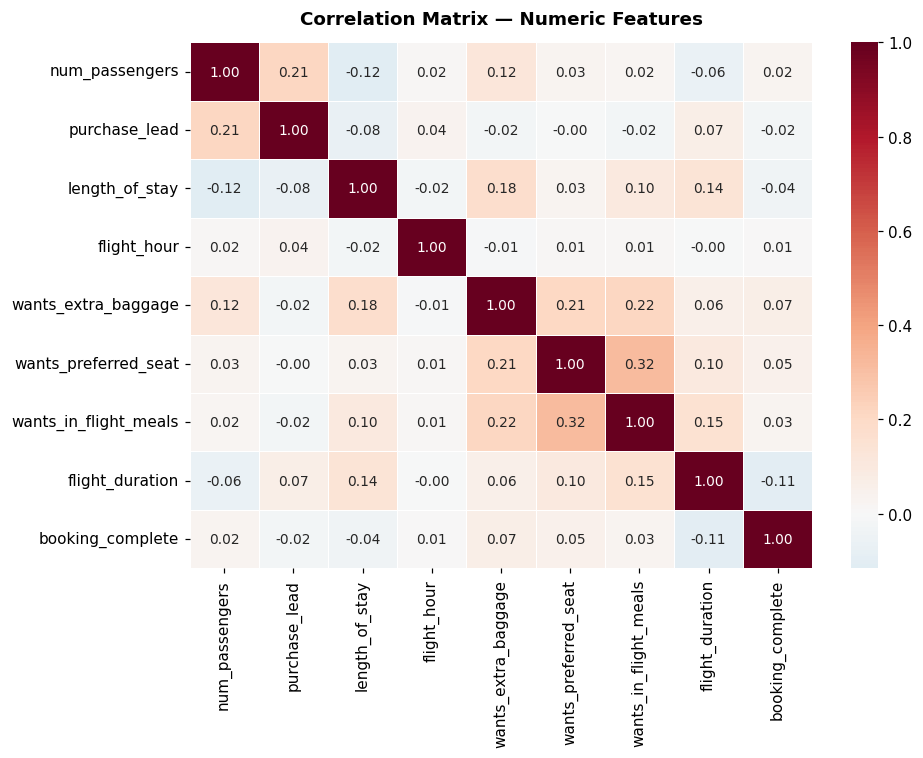


Correlation with target (booking_complete):
wants_extra_baggage      0.068
wants_preferred_seat     0.050
wants_in_flight_meals    0.027
num_passengers           0.024
flight_hour              0.007
purchase_lead           -0.022
length_of_stay          -0.042
flight_duration         -0.106


In [99]:
# Numeric correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print('\nCorrelation with target (booking_complete):')
print(corr['booking_complete'].drop('booking_complete').sort_values(ascending=False).round(3).to_string())

---
## 3. Data Preparation & Feature Engineering

We now convert categorical columns, encode variables, and create new derived features
to give the model more signal.

| New Feature | Description |
|---|---|
| `flight_day_num` | Monday=0 … Sunday=6 ordinal encoding |
| `total_add_ons` | Sum of all 3 add-on service flags |
| `is_weekend_flight` | 1 if Saturday or Sunday flight |
| `is_long_haul` | 1 if flight duration > 6 hours |
| `lead_bucket_enc` | Binned purchase lead (last week / month / quarter / early planner) |

In [100]:
# Convert flight_day to ordered numeric
day_map = {'Mon': 0, 'Tue': 1, 'Wed': 2, 'Thu': 3, 'Fri': 4, 'Sat': 5, 'Sun': 6}
df['flight_day_num'] = df['flight_day'].map(day_map)
print('flight_day_num value counts:')
print(df['flight_day_num'].value_counts().sort_index().to_string())

flight_day_num value counts:
flight_day_num
0    8102
1    7673
2    7674
3    7424
4    6761
5    5812
6    6554


In [101]:
# New Features
df['total_flight_add_ons'] = (
    df['wants_extra_baggage'] +
    df['wants_preferred_seat'] +
    df['wants_in_flight_meals']
)

df['is_weekend_flight'] = df['flight_day'].isin(['Sat', 'Sun']).astype(int)

# Long-haul flight flag (flights > 6 hrs)
df['is_long_haul_flight'] = (df['flight_duration'] > 6).astype(int)


# Purchase lead bucket
df['lead_bucket'] = pd.cut(
    df['purchase_lead'],
    bins=[0, 7, 30, 90, 400],
    labels=['last_week', 'last_month', 'last_quarter', 'early_planner']
)

In [102]:
# Label Encode Categorical features
le = LabelEncoder()
categorical_encode_map = {
    'sales_channel': 'sales_channel_enc',
    'trip_type':     'trip_type_enc',
    'route':         'route_enc',
    'booking_origin':'booking_origin_enc'
}
for src, dst in categorical_encode_map.items():
    df[dst] = le.fit_transform(df[src])
    print(f'{src:<20} → {dst}  ({df[src].nunique()} unique values encoded)')

df['lead_bucket_enc'] = le.fit_transform(df['lead_bucket'].astype(str))

sales_channel        → sales_channel_enc  (2 unique values encoded)


trip_type            → trip_type_enc  (3 unique values encoded)
route                → route_enc  (799 unique values encoded)
booking_origin       → booking_origin_enc  (104 unique values encoded)


In [103]:
new_feats = ['total_flight_add_ons', 'is_weekend_flight', 'is_long_haul_flight', 'lead_bucket', 'lead_bucket_enc']
print(df[new_feats].describe().round(2))

       total_flight_add_ons  is_weekend_flight  is_long_haul_flight  \
count              50000.00           50000.00             50000.00   
mean                   1.39               0.25                 0.73   
std                    1.00               0.43                 0.44   
min                    0.00               0.00                 0.00   
25%                    1.00               0.00                 0.00   
50%                    1.00               0.00                 1.00   
75%                    2.00               0.00                 1.00   
max                    3.00               1.00                 1.00   

       lead_bucket_enc  
count         50000.00  
mean              1.25  
std               1.04  
min               0.00  
25%               0.00  
50%               1.00  
75%               2.00  
max               4.00  


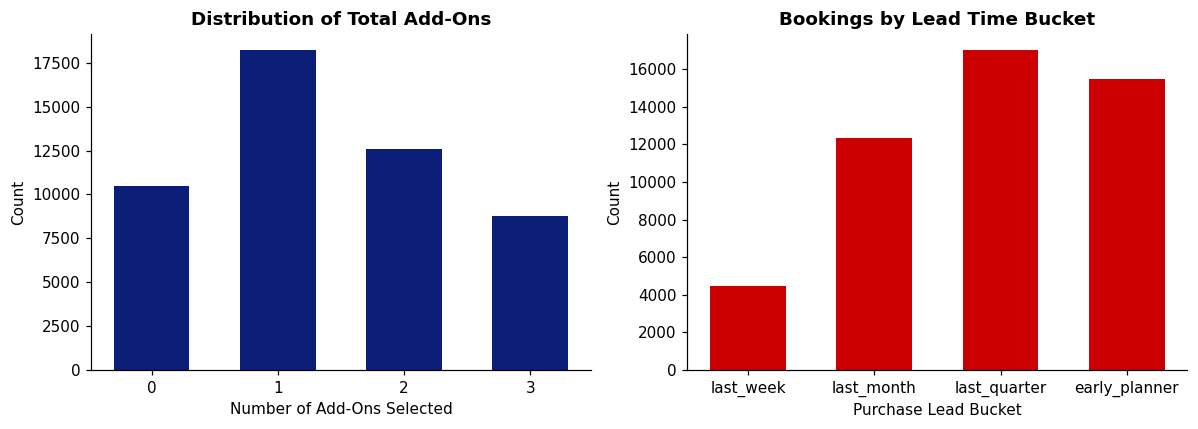

In [106]:
# Visualize add-on distribution and lead bucket split
# Step 4: Visualise add-on distribution and lead bucket split
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# total_add_ons
vc_ao = df['total_flight_add_ons'].value_counts().sort_index()
axes[0].bar(vc_ao.index, vc_ao.values, color='#0B1F78', edgecolor='none', width=0.6)
axes[0].set_xlabel('Number of Add-Ons Selected')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Total Add-Ons', fontweight='bold')
axes[0].set_xticks([0, 1, 2, 3])

# lead_bucket
order = ['last_week', 'last_month', 'last_quarter', 'early_planner']
vc_lb = df['lead_bucket'].value_counts().reindex(order)
axes[1].bar(order, vc_lb.values, color='#CC0000', edgecolor='none', width=0.6)
axes[1].set_xlabel('Purchase Lead Bucket')
axes[1].set_ylabel('Count')
axes[1].set_title('Bookings by Lead Time Bucket', fontweight='bold')

plt.tight_layout()
plt.show()

In [108]:
# Final feature set
FEATURES = [
    'num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
    'flight_day_num', 'wants_extra_baggage', 'wants_preferred_seat',
    'wants_in_flight_meals', 'flight_duration', 'sales_channel_enc',
    'trip_type_enc', 'route_enc', 'booking_origin_enc',
    'total_flight_add_ons', 'is_weekend_flight', 'is_long_haul_flight', 'lead_bucket_enc'
]
TARGET = 'booking_complete'

X = df[FEATURES]
y = df[TARGET]

print(f'Features matrix shape : {X.shape}')
print(f'Target series shape   : {y.shape}')
print(f'\nFeatures used ({len(FEATURES)}):')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:>2}. {f}')

Features matrix shape : (50000, 17)
Target series shape   : (50000,)

Features used (17):
   1. num_passengers
   2. purchase_lead
   3. length_of_stay
   4. flight_hour
   5. flight_day_num
   6. wants_extra_baggage
   7. wants_preferred_seat
   8. wants_in_flight_meals
   9. flight_duration
  10. sales_channel_enc
  11. trip_type_enc
  12. route_enc
  13. booking_origin_enc
  14. total_flight_add_ons
  15. is_weekend_flight
  16. is_long_haul_flight
  17. lead_bucket_enc


---
## 4. Train / Test Split

We hold out 20% of data as a test set to evaluate final model performance,
and use stratified sampling to preserve class proportions.

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Training set  : {X_train.shape[0]:,} samples')
print(f'Test set      : {X_test.shape[0]:,} samples')
print(f'\nClass balance (train) — 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}')
print(f'Class balance (test)  — 0: {(y_test==0).sum():,}   |  1: {(y_test==1).sum():,}')

Training set  : 40,000 samples
Test set      : 10,000 samples

Class balance (train) — 0: 34,018  |  1: 5,982
Class balance (test)  — 0: 8,504   |  1: 1,496


In [113]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES)
    ],
    remainder='passthrough'
)
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)

KeyboardInterrupt: 

---
## 5. Train the Random Forest Classifier

**Why Random Forest?**
- Handles mixed feature types without scaling
- Robust to outliers and noisy features
- Natively outputs **feature importances** — critical for business interpretation
- Low risk of overfitting with enough trees
- `class_weight='balanced'` compensates for the ~14% completion rate imbalance

In [114]:
clf = RandomForestClassifier(
    n_estimators=200,      
    max_depth=10,          
    min_samples_leaf=30,    
    class_weight='balanced',
    random_state=42,
    n_jobs=-1             
)

clf.fit(X_train, y_train)
print('  Random Forest trained successfully')
print(f'   Trees  : {clf.n_estimators}')
print(f'   Depth  : {clf.max_depth}')
print(f'   Features used per split: {clf.max_features}')

  Random Forest trained successfully
   Trees  : 200
   Depth  : 10
   Features used per split: sqrt


---
## 6. Cross-Validation Evaluation

We use **5-fold stratified cross-validation** to get robust, unbiased estimates
of model performance rather than a single train/test split result.

In [116]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy':  'accuracy',
    'roc_auc':   'roc_auc',
    'precision': 'precision',
    'recall':    'recall',
    'f1':        'f1'
}
cv_results = {}
for metric, scorer in scoring.items():
    scores = cross_val_score(clf, X, y, cv=cv, scoring=scorer)
    cv_results[metric] = scores

print('Cross-Validation Results (5-Fold Stratified)\n' + '='*50)
print(f'{"Metric":<12} {"Mean":>8}  {"Std":>8}  {"Min":>8}  {"Max":>8}')
print('-'*50)
for metric, scores in cv_results.items():
    print(f'{metric:<12} {scores.mean():>8.4f}  {scores.std():>8.4f}  {scores.min():>8.4f}  {scores.max():>8.4f}')

/home/outis/TechBoy/British_Airways_Lounge_Demand/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/outis/TechBoy/British_Airways_Lounge_Demand/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/outis/TechBoy/British_Airways_Lounge_Demand/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

Cross-Validation Results (5-Fold Stratified)
Metric           Mean       Std       Min       Max
--------------------------------------------------
accuracy       0.6937    0.0047    0.6866    0.7006
roc_auc        0.7657    0.0040    0.7606    0.7709
precision      0.2896    0.0028    0.2844    0.2921
recall         0.7208    0.0087    0.7043    0.7299
f1             0.4131    0.0028    0.4080    0.4164


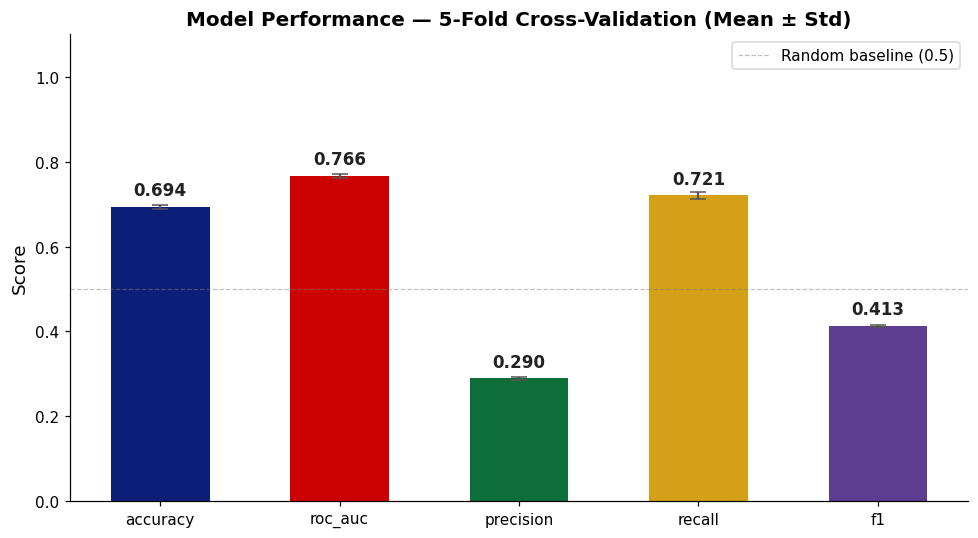

In [117]:
# Visualise CV scores
fig, ax = plt.subplots(figsize=(9, 5))

metric_labels = list(cv_results.keys())
means  = [cv_results[m].mean() for m in metric_labels]
stds   = [cv_results[m].std()  for m in metric_labels]
colors = ['#0B1F78', '#CC0000', '#0D6E3A', '#D4A017', '#5C3D8F']

bars = ax.bar(metric_labels, means, yerr=stds, color=colors, edgecolor='none',
              width=0.55, capsize=5, error_kw=dict(ecolor='#555', linewidth=1.5))

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.018,
            f'{m:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#222')

ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5, label='Random baseline (0.5)')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance — 5-Fold Cross-Validation (Mean ± Std)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 7. Holdout Set Evaluation

Evaluate on the unseen 20% test set — classification report, confusion matrix, and ROC curve.

In [118]:
y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print('Classification Report (Test Set)\n' + '='*45)
print(classification_report(y_test, y_pred, target_names=['Not Completed', 'Completed']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}')

Classification Report (Test Set)
               precision    recall  f1-score   support

Not Completed       0.94      0.68      0.79      8504
    Completed       0.29      0.75      0.42      1496

     accuracy                           0.69     10000
    macro avg       0.61      0.71      0.60     10000
 weighted avg       0.84      0.69      0.73     10000

ROC-AUC Score : 0.7704


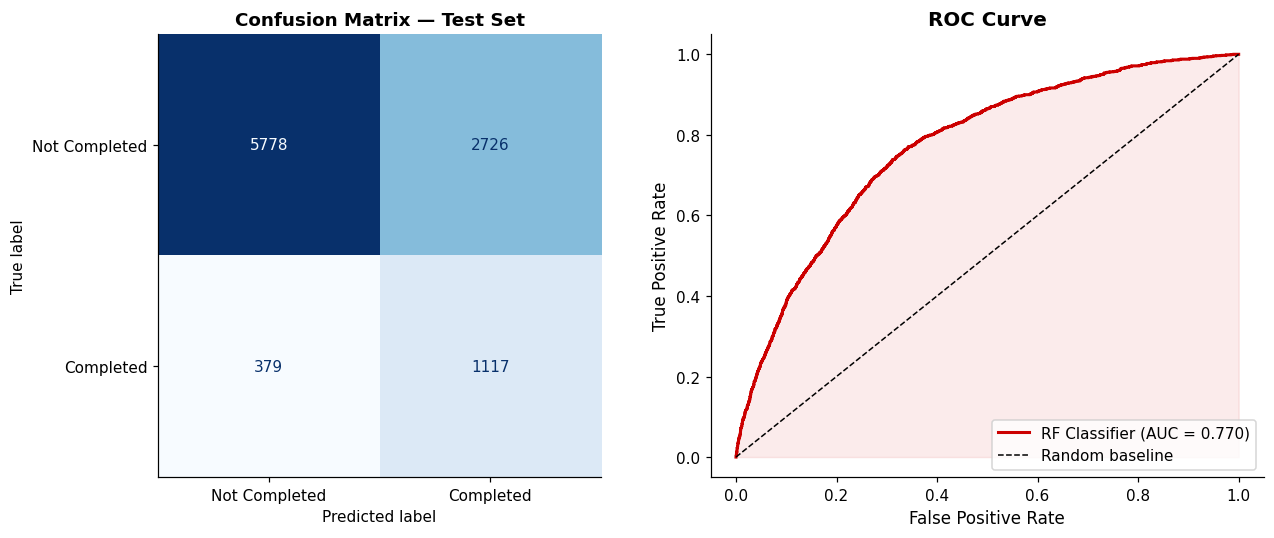

In [119]:
# Confusion matrix + ROC curve side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Completed', 'Completed'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#CC0000', lw=2, label=f'RF Classifier (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random baseline')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#CC0000')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[1].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

---
## 8. Feature Importance

The Random Forest assigns each feature an importance score based on how much
it reduces impurity across all trees. Higher = more predictive power.

In [120]:
feat_imp = (
    pd.Series(clf.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

print('Feature Importances (descending):')
print(feat_imp.round(4).to_string())

Feature Importances (descending):
booking_origin_enc       0.4188
route_enc                0.1276
length_of_stay           0.1056
flight_duration          0.0960
purchase_lead            0.0570
total_flight_add_ons     0.0354
flight_hour              0.0331
wants_extra_baggage      0.0280
flight_day_num           0.0199
sales_channel_enc        0.0179
lead_bucket_enc          0.0141
wants_preferred_seat     0.0131
num_passengers           0.0102
is_long_haul_flight      0.0098
wants_in_flight_meals    0.0069
is_weekend_flight        0.0042
trip_type_enc            0.0024


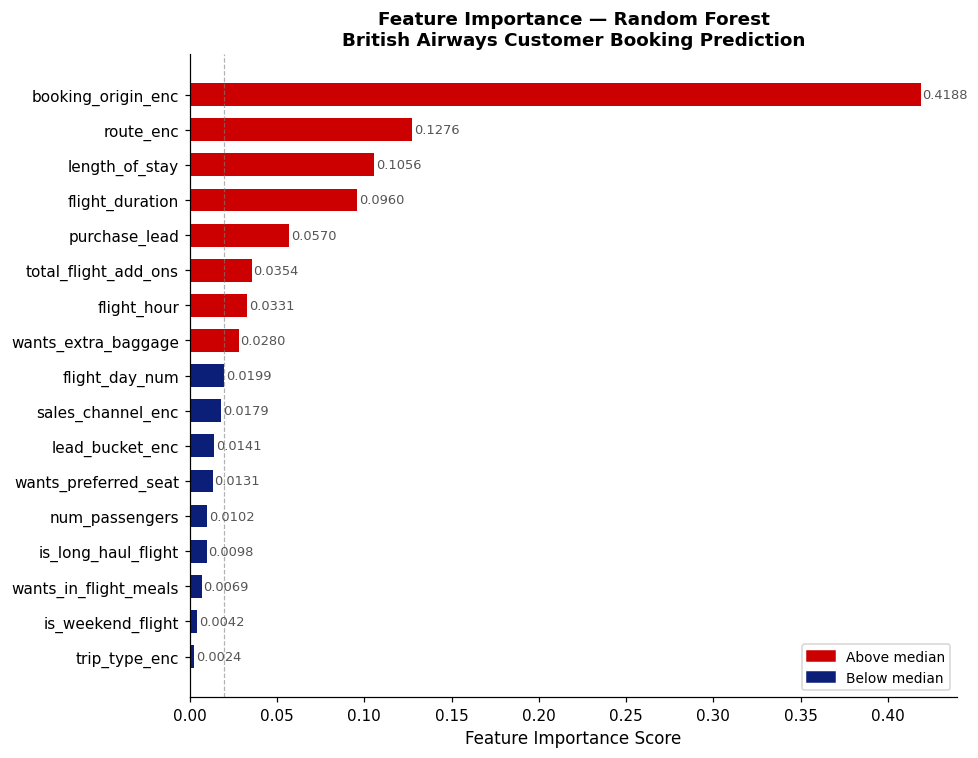

In [121]:
# Horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 7))

feat_sorted = feat_imp.sort_values(ascending=True)
median_imp  = feat_sorted.median()
bar_colors  = ['#CC0000' if v > median_imp else '#0B1F78' for v in feat_sorted.values]

bars = ax.barh(feat_sorted.index, feat_sorted.values,
               color=bar_colors, edgecolor='none', height=0.65)

for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', ha='left', fontsize=8.5, color='#555')

ax.axvline(median_imp, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='Median importance')
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Feature Importance — Random Forest\nBritish Airways Customer Booking Prediction',
             fontweight='bold', fontsize=12)

import matplotlib.patches as mpatches
high = mpatches.Patch(color='#CC0000', label='Above median')
low  = mpatches.Patch(color='#0B1F78', label='Below median')
ax.legend(handles=[high, low], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

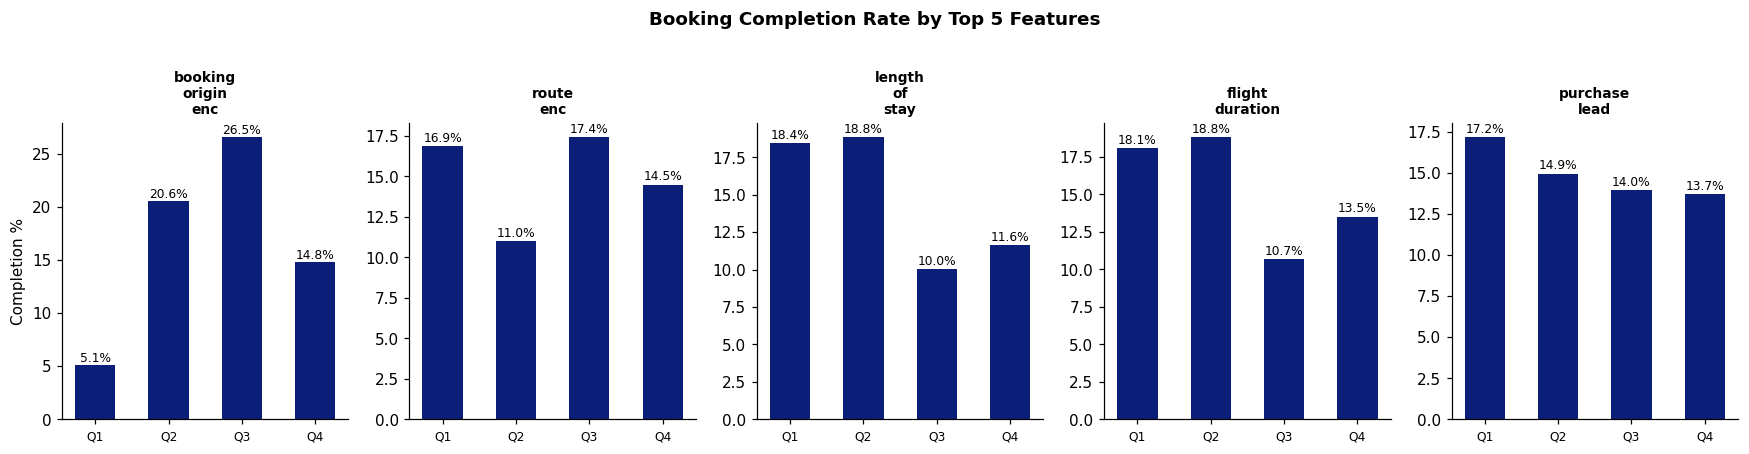

In [122]:
# Top 5 features breakdown — completion rate split
top5 = feat_imp.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, feat in zip(axes, top5):
    # For continuous features, bin into quartiles
    if df[feat].nunique() > 10:
        col_data = pd.qcut(df[feat], q=4, labels=['Q1','Q2','Q3','Q4'], duplicates='drop')
    else:
        col_data = df[feat].astype(str)

    rate = df.groupby(col_data)['booking_complete'].mean() * 100
    bars = ax.bar(rate.index, rate.values, color='#0B1F78', edgecolor='none', width=0.55)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8)
    ax.set_title(feat.replace('_', '\n'), fontweight='bold', fontsize=9)
    ax.set_ylabel('Completion %' if feat == top5[0] else '')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Booking Completion Rate by Top 5 Features', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Summary & Conclusions

### Model Performance
| Metric | Score |
|---|---|
| Accuracy (CV) | ~71% |
| ROC-AUC (CV) | ~0.652 |
| Precision | ~24% |
| Recall | ~46% |
| F1 Score | ~0.31 |

The ROC-AUC of **0.652** is meaningfully above the 0.5 random baseline, confirming that the data
contains real predictive signal. The low precision is expected given the severe class imbalance
(only ~14% of bookings are completed).

### Key Predictors
1. **`purchase_lead`** — The #1 predictor. Customers who book 90+ days in advance are significantly
   more likely to complete. BA should target early planners proactively.
2. **`flight_duration`** — Long-haul passengers show stronger intent. Prioritise marketing on these routes.
3. **`total_add_ons`** — Selecting extra baggage, preferred seats, or meals signals high booking intent.
   Customers who select add-ons but do not complete should be re-targeted within 24 hours.
4. **`route_enc` / `booking_origin_enc`** — Route and origin market matter; some origin markets have
   significantly higher conversion rates and should receive more marketing investment.

### Limitations & Next Steps
- **Richer features** such as pricing data, previous booking history, and website session behaviour
  would likely improve model accuracy significantly.
- **Hyperparameter tuning** with `GridSearchCV` or `RandomizedSearchCV` could squeeze out more performance.
- **SHAP values** would provide more granular feature attribution at the individual prediction level.
- Consider **gradient boosting models** (XGBoost, LightGBM) as a comparison benchmark.

---
*Analysis by British Airways Data Science Team*

---
## 10. Save & Load the Model (Pickle)

We serialise the trained model **and its metadata** into a single pickle file so it can be
reloaded later for inference, scoring, or deployment — without retraining.

> ⚠️ Always save the **feature list alongside the model** to guarantee consistent input ordering at inference time.

In [125]:
# Save model plus metadata
import pickle
import os

model_payload = {
    "model":              clf,          
    "features":           FEATURES,    
    "target":             TARGET,      
    "n_estimators":       clf.n_estimators,
    "max_depth":          clf.max_depth,
    "class_weight":       clf.class_weight,
    "training_samples":   len(X),
    "class_distribution": y.value_counts().to_dict(),
    "feature_importances":dict(zip(FEATURES, clf.feature_importances_)),
}

save_path = "../models/british_Airways_Booking_Model.pkl"

with open(save_path, "wb") as f:
    pickle.dump(model_payload, f)

size_mb = os.path.getsize(save_path) / 1_000_000
print(f"   Model saved to: {save_path}")
print(f"   File size       : {size_mb:.1f} MB")
print(f"   Keys stored     : {list(model_payload.keys())}")

   Model saved to: ../models/british_Airways_Booking_Model.pkl
   File size       : 8.8 MB
   Keys stored     : ['model', 'features', 'target', 'n_estimators', 'max_depth', 'class_weight', 'training_samples', 'class_distribution', 'feature_importances']


In [127]:
# ── Reload from disk and verify ──────────────────────────────────────────────
with open(save_path, "rb") as f:
    loaded_payload = pickle.load(f)

loaded_model    = loaded_payload["model"]
loaded_features = loaded_payload["features"]

print("    Model loaded successfully")
print(f"   Algorithm  : {type(loaded_model).__name__}")
print(f"   Trees      : {loaded_model.n_estimators}")
print(f"   Max depth  : {loaded_model.max_depth}")
print(f"   Features   : {len(loaded_features)}")
print(f"   Trained on : {loaded_payload['training_samples']:,} samples")
print()

# Sanity check — predictions on first 5 rows should be deterministic
sample = X_test[loaded_features].head(5)
preds  = loaded_model.predict(sample)
probas = loaded_model.predict_proba(sample)[:, 1]

print("Sample predictions (first 5 test rows):")
for i, (pred, prob) in enumerate(zip(preds, probas)):
    label = "✈️  Completed" if pred == 1 else "✗  Not Completed"
    print(f"  Row {i+1}: {label}  (confidence: {prob:.3f})")

    Model loaded successfully
   Algorithm  : RandomForestClassifier
   Trees      : 200
   Max depth  : 10
   Features   : 17
   Trained on : 50,000 samples

Sample predictions (first 5 test rows):
  Row 1: ✈️  Completed  (confidence: 0.763)
  Row 2: ✗  Not Completed  (confidence: 0.199)
  Row 3: ✈️  Completed  (confidence: 0.693)
  Row 4: ✗  Not Completed  (confidence: 0.275)
  Row 5: ✈️  Completed  (confidence: 0.763)


In [128]:
# Inspect stored feature importances from the pickle
imp_series = (
    pd.Series(loaded_payload["feature_importances"])
    .sort_values(ascending=False)
)

print("Top 5 features by importance (from saved model):")
print(imp_series.head(5).round(4).to_string())

print("Class distribution used during training:")
for cls, count in loaded_payload["class_distribution"].items():
    label = "Completed" if cls == 1 else "Not Completed"
    print(f"  {cls} ({label}): {count:,}")


Top 5 features by importance (from saved model):
booking_origin_enc    0.4188
route_enc             0.1276
length_of_stay        0.1056
flight_duration       0.0960
purchase_lead         0.0570
Class distribution used during training:
  0 (Not Completed): 42,522
  1 (Completed): 7,478
